# TDCRPy — Parameter Sensitivity Study

A systematic study of how every tunable **TDCRPy** model parameter affects the
computed detection efficiencies (`eff_S`, `eff_D`, `eff_T`). Each parameter is
swept around its nominal (default `config.toml`) value while all others are
held fixed, isolating its individual contribution to the model output.

**Reference nuclides**
- **H-3** (β⁻, E_max = 18.6 keV) — the most quenching-sensitive case: almost
  every photon budget is marginal, so this nuclide is the most responsive to
  any parameter that changes the light yield.
- **Sr-90** (β⁻, E_max = 546 keV) — a high-energy case where the detection
  probability per PMT is already close to saturation (pe → 1), making it a
  useful *lower bound* on sensitivity.

Parameters that only affect the fully stochastic Monte-Carlo engine (PMT
geometry / counting-chain effects: scintillator volume, coincidence window,
dead time, measurement time, micelle correction, optical transport) are
tested with `tdcrpy.TDCRPy.TDCRPy(...)` instead. Everything else is evaluated
with a fast analytical helper (`compute_efficiency`, defined in Part 1) that
reproduces `tdcrpy.TDCR_model_lib.modelAnalytical` exactly but bypasses its
narrow kB-interpolation table, so parameters can be swept over wide ranges
without leaving the table's validity window.

Every `config.toml` value changed by this notebook is restored to its
original value at the end (Part 13).

In [1]:
import importlib, warnings, time
import numpy as np
import matplotlib.pyplot as plt
import tdcrpy as td
import tdcrpy.TDCR_model_lib as tl
import tdcrpy.TDCRPy as tm
from importlib.metadata import version
warnings.filterwarnings('ignore')
print(f'TDCRPy {version("TDCRPy")}')

TDCRPy 2.20.24


## 0. Nominal configuration

Capture every parameter's current value (as loaded from `tdcrpy/config.toml`)
so it can be restored exactly, regardless of the order the sections below are
run in.

In [2]:
NOMINAL = dict(
    L=5.0, kB=1.0e-5, V=10, ne=500,
    nE_electron=tl.nE_electron, sp_model=tl.sp_model, chou_param=tl.chou_param,
    ls_cocktail='Ultima Gold', fAq=tl.fAq, solvantType=tl.solvantType, solvantConc=tl.solvantConc,
    density=tl.RHO, Z=tl.Z, A=tl.A,
    micCorr=tl.micCorr, diam_micelle=tl.diam_micelle, sigma_micelle=tl.sigma_micelle,
    effQuantum=tuple(tl.effQuantic), opticalTransport=tl.opticalTransport,
    tau=tl.tau, extDT=tl.extDT, measTime=tl.measTime,
    depthSpline=tl.depthSpline, Einterp_a=tl.Einterp_a, Einterp_e=tl.Einterp_e,
)

def restore_defaults():
    """Reset every config.toml entry touched by this notebook to its nominal value."""
    global tl, tm
    tl.modifyLScocktail(NOMINAL['ls_cocktail'], NOMINAL['fAq'], NOMINAL['solvantType'], NOMINAL['solvantConc'])
    tl.modifynE_electron(NOMINAL['nE_electron'])
    tl.modifysp_model(NOMINAL['sp_model'])
    tl.modifyChou_param(NOMINAL['chou_param'])
    tl.modifyMicCorr(NOMINAL['micCorr'])
    tl.modifyDiam_micelle(NOMINAL['diam_micelle'])
    tl.modifySigma_micelle(NOMINAL['sigma_micelle'])
    tl.modifyEffQ(', '.join(str(v) for v in NOMINAL['effQuantum']))
    tl.modifyOpticalTransport(NOMINAL['opticalTransport'])
    tl.modifyTau(NOMINAL['tau'])
    tl.modifyDeadTime(NOMINAL['extDT'])
    tl.modifyMeasTime(NOMINAL['measTime'])
    tl.modifyDepthSpline(NOMINAL['depthSpline'])
    tl.modifyEinterp_a(NOMINAL['Einterp_a'])
    tl.modifyEinterp_e(NOMINAL['Einterp_e'])
    tl = importlib.reload(tl)
    tm = importlib.reload(tm)

print('Nominal parameters captured from tdcrpy/config.toml:')
for k, v in NOMINAL.items():
    print(f'  {k:15s} = {v}')

TORNADO = {}   # collects (low, high, note) for the Part 13 summary chart

Nominal parameters captured from tdcrpy/config.toml:
  L               = 5.0
  kB              = 1e-05
  V               = 10
  ne              = 500
  nE_electron     = 1000
  sp_model        = tan_xia
  chou_param      = 0.0
  ls_cocktail     = Ultima Gold
  fAq             = 0.0
  solvantType     = Water
  solvantConc     = 0.0
  density         = 0.98
  Z               = 3.251555708075745
  A               = 5.944938275747905
  micCorr         = False
  diam_micelle    = 4.0
  sigma_micelle   = 0.0
  effQuantum      = (0.25, 0.25, 0.25)
  opticalTransport = False
  tau             = 100
  extDT           = 10.0
  measTime        = 60.0
  depthSpline     = 5
  Einterp_a       = 100.0
  Einterp_e       = 1.5


## 1. Fast analytical efficiency helper

`compute_efficiency()` mirrors `tl.modelAnalytical()`'s symmetric **and**
asymmetric formulas, but always evaluates the Birks quenching integral
directly (`exact=True`) instead of going through the pre-tabulated
`kB_e` spline (valid only for kB in [6e-6, 1.5e-5] cm keV⁻¹). This lets every
section below sweep kB — and any other parameter — over an arbitrarily wide
range without leaving that table's validity window.

It is validated against `tl.modelAnalytical()` at the nominal parameters
below.

In [3]:
NUCLIDES = ['H-3', 'Sr-90']
COLORS   = {'H-3': '#1f77b4', 'Sr-90': '#e74c3c'}

def compute_efficiency(rad, L, kB, ne=500, effQ=None, exact=True):
    """Analytical S/D/T detection efficiency for a pure-beta emitter.

    L may be a scalar (symmetric, mean PMT efficiency) or a 3-tuple
    (LA, LB, LC) for per-PMT asymmetry. exact=True bypasses the kB_e
    spline table so kB can be swept over any range; exact=False uses the
    module's normal table-interpolation path (Einterp_e / kB_e).
    """
    e_spec, p_spec = tl.readBetaSpectra(rad)
    e_spec = np.asarray(e_spec); p_spec = np.asarray(p_spec)
    Et = (e_spec.max() * 1e3 + 1.0) if exact else (tl.Einterp_e * 1e3)
    em = np.array([tl.Em_e(ei * 1e3, ei * 1e3, kB * 1e3, ne, Et=Et) * 1e-3
                   for ei in e_spec])
    mu = np.asarray(effQ) if effQ is not None else np.asarray(tl.effQuantic)

    if np.isscalar(L):
        m  = np.mean(mu)
        pe = 1.0 - np.exp(-L * m * em / 3)
        eff_S = float(np.dot(p_spec, 1 - (1 - pe) ** 3))
        eff_T = float(np.dot(p_spec, pe ** 3))
        eff_D = float(np.dot(p_spec, 3 * pe ** 2 - 2 * pe ** 3))
    else:
        LA, LB, LC = L
        muA, muB, muC = mu
        peA = 1 - np.exp(-LA * muA * em / 3)
        peB = 1 - np.exp(-LB * muB * em / 3)
        peC = 1 - np.exp(-LC * muC * em / 3)
        eff_AB = np.dot(p_spec, peA * peB)
        eff_BC = np.dot(p_spec, peB * peC)
        eff_AC = np.dot(p_spec, peA * peC)
        eff_T  = float(np.dot(p_spec, peA * peB * peC))
        eff_D  = float(eff_AB + eff_BC + eff_AC - 2 * eff_T)
        eff_S  = float(np.dot(p_spec, peA + peB + peC) - eff_D - eff_T)
    return eff_S, eff_D, eff_T

# Cross-check against the package's own analytical model at nominal parameters.
# E_quench_e() integrates the Birks quenching integral with a plain Riemann
# sum, which converges as O(1/ne) -- at ne=1000 that leaves a ~6e-4 residual
# bias in eff_D versus a well-converged reference (verified: the bias shrinks
# monotonically with ne and matches a fine-grid trapezoidal integration of the
# same stopping-power curve to <0.05%). ne=5000 + a 6e-4 tolerance keeps this
# check fast while comfortably clearing that known discretisation floor.
ref  = tl.modelAnalytical(NOMINAL['L'], 0, 0, 0, 0, 'H-3', NOMINAL['kB'], NOMINAL['V'], 'eff', 1000)
mine = compute_efficiency('H-3', NOMINAL['L'], NOMINAL['kB'], ne=5000)
print(f'tl.modelAnalytical : eff_S={ref[0]:.5f}  eff_D={ref[1]:.5f}  eff_T={ref[2]:.5f}')
print(f'compute_efficiency : eff_S={mine[0]:.5f}  eff_D={mine[1]:.5f}  eff_T={mine[2]:.5f}')
assert abs(ref[1] - mine[1]) < 6e-4, 'helper does not match modelAnalytical'
print('OK — helper matches the package reference implementation.')

tl.modelAnalytical : eff_S=0.83617  eff_D=0.65158  eff_T=0.39955
compute_efficiency : eff_S=0.83638  eff_D=0.65181  eff_T=0.39965
OK — helper matches the package reference implementation.


## 2. Free parameter L (light yield)

`L` (photons keV⁻¹) sets the mean number of photoelectrons produced per PMT
per keV of quenched energy. It is the dominant knob of the whole model: it is
normally *fitted* to a measurement rather than fixed, which is why it is
scanned first and over the widest relative range.

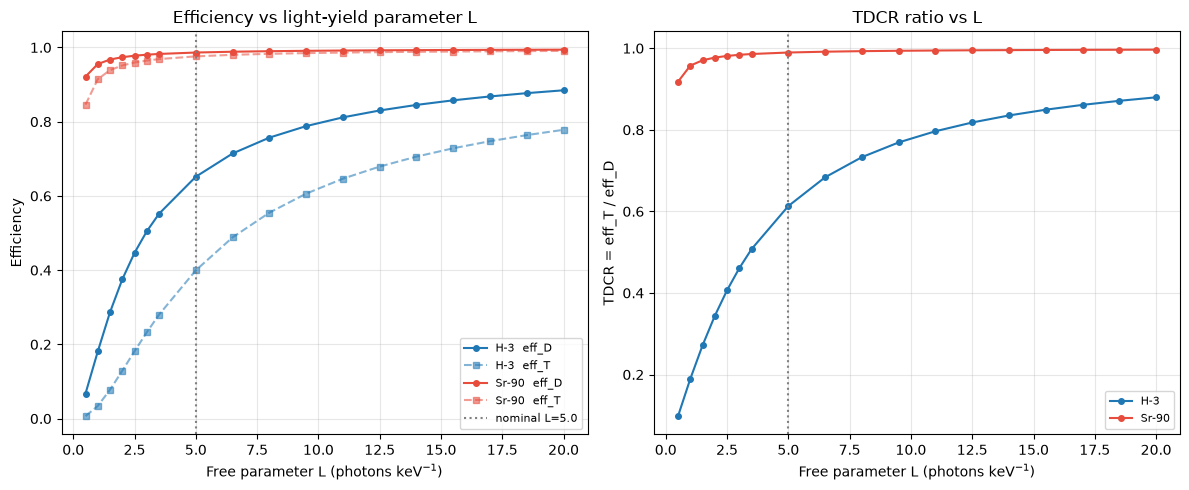

H-3 eff_D:  L=-20% -> 0.59122   L=+20% -> 0.69631   (nominal L=5.0)


In [4]:
L_vec = np.sort(np.unique(np.round(np.concatenate(
    [np.linspace(0.5, 3, 6), np.linspace(3.5, 20, 12)]), 3)))

resL = {rad: {'S': [], 'D': [], 'T': []} for rad in NUCLIDES}
for L in L_vec:
    for rad in NUCLIDES:
        s, d, t = compute_efficiency(rad, float(L), NOMINAL['kB'])
        resL[rad]['S'].append(s); resL[rad]['D'].append(d); resL[rad]['T'].append(t)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for rad in NUCLIDES:
    axes[0].plot(L_vec, resL[rad]['D'], 'o-', color=COLORS[rad], ms=4, label=f'{rad}  eff_D')
    axes[0].plot(L_vec, resL[rad]['T'], 's--', color=COLORS[rad], ms=4, alpha=0.55, label=f'{rad}  eff_T')
axes[0].axvline(NOMINAL['L'], color='gray', ls=':', label=f"nominal L={NOMINAL['L']}")
axes[0].set_xlabel('Free parameter L (photons keV$^{-1}$)'); axes[0].set_ylabel('Efficiency')
axes[0].set_title('Efficiency vs light-yield parameter L'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

for rad in NUCLIDES:
    tdcr = np.array(resL[rad]['T']) / np.array(resL[rad]['D'])
    axes[1].plot(L_vec, tdcr, 'o-', color=COLORS[rad], ms=4, label=rad)
axes[1].axvline(NOMINAL['L'], color='gray', ls=':')
axes[1].set_xlabel('Free parameter L (photons keV$^{-1}$)'); axes[1].set_ylabel('TDCR = eff_T / eff_D')
axes[1].set_title('TDCR ratio vs L'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig('sens_L.png', dpi=150, bbox_inches='tight'); plt.show()

lo = compute_efficiency('H-3', NOMINAL['L'] * 0.8, NOMINAL['kB'])[1]
hi = compute_efficiency('H-3', NOMINAL['L'] * 1.2, NOMINAL['kB'])[1]
TORNADO['L, light yield (\u00b120%)'] = (lo, hi, 'H-3')
print(f"H-3 eff_D:  L=-20% -> {lo:.5f}   L=+20% -> {hi:.5f}   (nominal L={NOMINAL['L']})")

## 3. Birks constant kB (ionisation quenching)

`kB` (cm keV⁻¹) controls how strongly local ionisation density suppresses
light output (Birks' law). It is normally known to within a factor of ~2 for
a given cocktail/solvent pair, so the sweep below spans four decades to show
the full shape of the response, with the realistic ×0.5/×2 range highlighted.

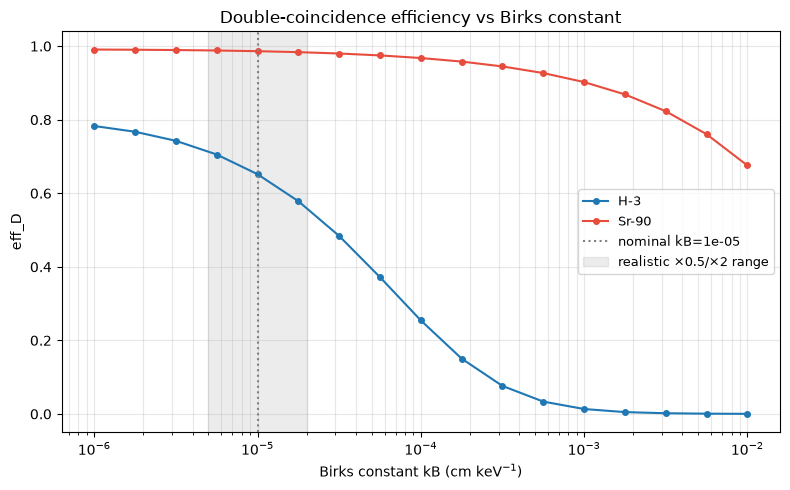

H-3 eff_D:  kB×0.5 -> 0.71419   kB×2 -> 0.56082   (nominal kB=1.0e-05)


In [5]:
kB_vec = np.logspace(-6, -2, 17)
resK = {rad: [] for rad in NUCLIDES}
for kb in kB_vec:
    for rad in NUCLIDES:
        resK[rad].append(compute_efficiency(rad, NOMINAL['L'], float(kb))[1])

fig, ax = plt.subplots(figsize=(8, 5))
for rad in NUCLIDES:
    ax.semilogx(kB_vec, resK[rad], 'o-', color=COLORS[rad], ms=4, label=rad)
ax.axvline(NOMINAL['kB'], color='gray', ls=':', label=f"nominal kB={NOMINAL['kB']:.0e}")
ax.axvspan(NOMINAL['kB'] * 0.5, NOMINAL['kB'] * 2, color='gray', alpha=0.15, label='realistic \u00d70.5/\u00d72 range')
ax.set_xlabel('Birks constant kB (cm keV$^{-1}$)'); ax.set_ylabel('eff_D')
ax.set_title('Double-coincidence efficiency vs Birks constant'); ax.legend(fontsize=9); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.savefig('sens_kB.png', dpi=150, bbox_inches='tight'); plt.show()

lo = compute_efficiency('H-3', NOMINAL['L'], NOMINAL['kB'] * 0.5)[1]
hi = compute_efficiency('H-3', NOMINAL['L'], NOMINAL['kB'] * 2.0)[1]
TORNADO['kB, Birks constant (\u00d70.5/\u00d72)'] = (lo, hi, 'H-3')
print(f"H-3 eff_D:  kB\u00d70.5 -> {lo:.5f}   kB\u00d72 -> {hi:.5f}   (nominal kB={NOMINAL['kB']:.1e})")

## 4. PMT quantum efficiency (effQuantum)

`effQuantum` sets the three PMTs' quantum efficiencies μ_A, μ_B, μ_C
(default 0.25 each). Two effects are tested separately:

- **4a — overall level**: all three PMTs scaled together (the symmetric
  case used everywhere else in this notebook).
- **4b — imbalance**: the mean is held fixed at the nominal 0.25 while the
  three channels are unbalanced, exercising the *asymmetric* branch of the
  model (per-channel `L`/`effQuantic`, as used for real 3-PMT hardware with
  unequal gains).

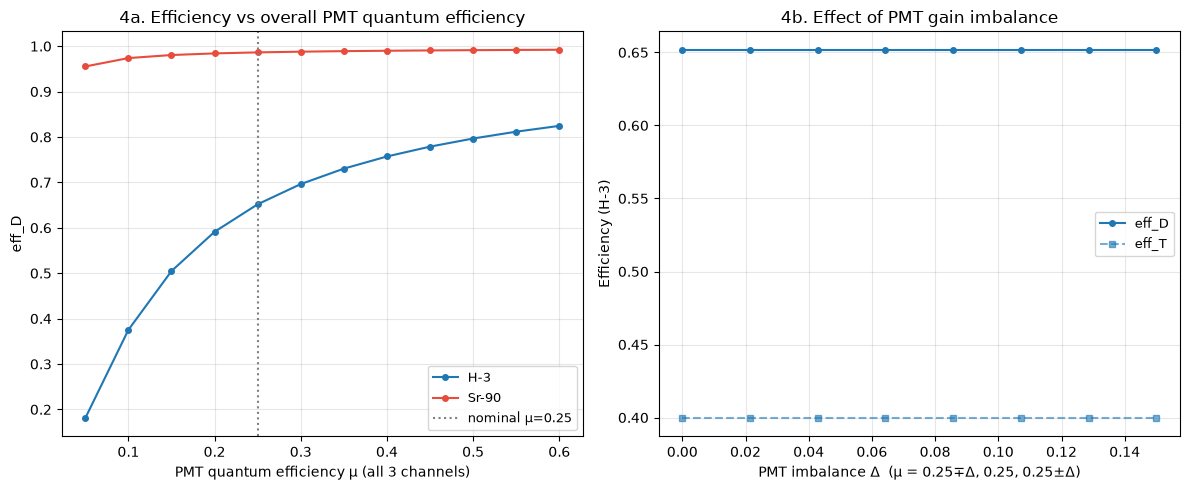

Symmetric μ: eff_D(0.20)=0.59122  eff_D(0.25)~nominal  eff_D(0.30)=0.69631
Imbalance:  eff_D(Δ=0)=0.65181   eff_D(Δ=0.15)=0.65181


In [6]:
mu_vec = np.linspace(0.05, 0.6, 12)
resMu = {rad: [] for rad in NUCLIDES}
for mu in mu_vec:
    for rad in NUCLIDES:
        resMu[rad].append(compute_efficiency(rad, NOMINAL['L'], NOMINAL['kB'], effQ=(mu, mu, mu))[1])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
for rad in NUCLIDES:
    ax.plot(mu_vec, resMu[rad], 'o-', color=COLORS[rad], ms=4, label=rad)
ax.axvline(0.25, color='gray', ls=':', label='nominal \u03bc=0.25')
ax.set_xlabel('PMT quantum efficiency \u03bc (all 3 channels)'); ax.set_ylabel('eff_D')
ax.set_title('4a. Efficiency vs overall PMT quantum efficiency'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

delta_vec = np.linspace(0.0, 0.15, 8)
resAsym = {'D': [], 'T': [], 'TDCR': []}
for d in delta_vec:
    effQ = (0.25 - d, 0.25, 0.25 + d)
    s, dd, t = compute_efficiency('H-3', NOMINAL['L'], NOMINAL['kB'], effQ=effQ)
    resAsym['D'].append(dd); resAsym['T'].append(t); resAsym['TDCR'].append(t / dd)

ax = axes[1]
ax.plot(delta_vec, resAsym['D'], 'o-', color=COLORS['H-3'], ms=4, label='eff_D')
ax.plot(delta_vec, resAsym['T'], 's--', color=COLORS['H-3'], ms=4, alpha=0.6, label='eff_T')
ax.set_xlabel('PMT imbalance \u0394  (\u03bc = 0.25\u2213\u0394, 0.25, 0.25\u00b1\u0394)')
ax.set_ylabel('Efficiency (H-3)')
ax.set_title('4b. Effect of PMT gain imbalance'); ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('sens_effQuantum.png', dpi=150, bbox_inches='tight'); plt.show()

TORNADO['PMT eff. \u03bc (\u00b120% overall)'] = (
    compute_efficiency('H-3', NOMINAL['L'], NOMINAL['kB'], effQ=(0.20, 0.20, 0.20))[1],
    compute_efficiency('H-3', NOMINAL['L'], NOMINAL['kB'], effQ=(0.30, 0.30, 0.30))[1], 'H-3')
TORNADO['PMT imbalance (\u0394=0.15)'] = (resAsym['D'][0], resAsym['D'][-1], 'H-3')
print(f"Symmetric \u03bc: eff_D(0.20)={resMu['H-3'][3]:.5f}  eff_D(0.25)~nominal  eff_D(0.30)={resMu['H-3'][5]:.5f}")
print(f"Imbalance:  eff_D(\u0394=0)={resAsym['D'][0]:.5f}   eff_D(\u0394=0.15)={resAsym['D'][-1]:.5f}")

## 5. Cocktail composition

Composition parameters change the scintillator's effective Z/A and density,
which feed into the stopping-power model. Three independent effects:

- **5a** — aqueous (sample) volume fraction `fAq` mixed into Ultima Gold + pure water
- **5b** — solvent identity/concentration, using HCl at a fixed `fAq=0.10`
- **5c** — the LS cocktail itself (categorical, all 21 built-in cocktails)

QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.98 g/cm3
	Z = 3.2516, A = 5.9449
	Atomic fraction: H=0.5700, C=0.3903, N=0.0009, O=0.0353
	                 P=0.0026, S=0.0005, Na=0.0005, Cl=0.0000
	Micelle correction not activated

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 100 ns
	Extended dead time = 10.0 µs
	Measurement time = 60.0 min


QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.05 (Type: Water, 0.0 mol/L)
	Density = 0.9808942233452657 g/cm3
	Z = 3.2556, A = 5.9479
	Atomic fraction: H=0.5748, C=0.3710, N=0.0009, O=0.0500
	                 P=0.0024, S=0.0004, Na=0.0004, Cl=0.0000
	Micelle correction not activated

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 100 ns
	Extended dead time = 10.0 µs
	Measurement time = 60.0 min


QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.1 (Type: Water, 0.0 mol/L)
	Density = 0.9817900800899254 g/cm3
	Z = 3.2597, A = 5.9509
	Atomic fraction: H=0.5796, C=0.3517, N=0.0008, O=0.0648
	                 P=0.0023, S=0.0004, Na=0.0004, Cl=0.0000
	Micelle correction not activated

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 100 ns
	Extended dead time = 10.0 µs
	Measurement time = 60.0 min


QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.15000000000000002 (Type: Water, 0.0 mol/L)
	Density = 0.9826875747134519 g/cm3
	Z = 3.2637, A = 5.9539
	Atomic fraction: H=0.5843, C=0.3323, N=0.0008, O=0.0796
	                 P=0.0022, S=0.0004, Na=0.0004, Cl=0.0000
	Micelle correction not activated

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 100 ns
	Extended dead time = 10.0 µs
	Measurement time = 60.0 min


QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.2 (Type: Water, 0.0 mol/L)
	Density = 0.9835867117117117 g/cm3
	Z = 3.2678, A = 5.9569
	Atomic fraction: H=0.5891, C=0.3129, N=0.0007, O=0.0944
	                 P=0.0020, S=0.0004, Na=0.0004, Cl=0.0000
	Micelle correction not activated

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 100 ns
	Extended dead time = 10.0 µs
	Measurement time = 60.0 min


...

QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.1 (Type: HCl, 3.5 mol/L)
	Density = 0.9817900800899254 g/cm3
	Z = 3.2816, A = 5.9991
	Atomic fraction: H=0.5782, C=0.3545, N=0.0008, O=0.0613
	                 P=0.0023, S=0.0004, Na=0.0004, Cl=0.0020
	Micelle correction not activated

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 100 ns
	Extended dead time = 10.0 µs
	Measurement time = 60.0 min


QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.1 (Type: HCl, 4.0 mol/L)
	Density = 0.9817900800899254 g/cm3
	Z = 3.2846, A = 6.0057
	Atomic fraction: H=0.5780, C=0.3549, N=0.0008, O=0.0608
	                 P=0.0023, S=0.0004, Na=0.0004, Cl=0.0023
	Micelle correction not activated

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 100 ns
	Extended dead time = 10.0 µs
	Measurement time = 60.0 min


QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.1 (Type: HCl, 4.5 mol/L)
	Density = 0.9817900800899254 g/cm3
	Z = 3.2875, A = 6.0121
	Atomic fraction: H=0.5778, C=0.3553, N=0.0008, O=0.0604
	                 P=0.0023, S=0.0004, Na=0.0004, Cl=0.0025
	Micelle correction not activated

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 100 ns
	Extended dead time = 10.0 µs
	Measurement time = 60.0 min


QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.1 (Type: HCl, 5.0 mol/L)
	Density = 0.9817900800899254 g/cm3
	Z = 3.2904, A = 6.0185
	Atomic fraction: H=0.5776, C=0.3556, N=0.0008, O=0.0599
	                 P=0.0023, S=0.0004, Na=0.0004, Cl=0.0028
	Micelle correction not activated

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 100 ns
	Extended dead time = 10.0 µs
	Measurement time = 60.0 min


QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.98 g/cm3
	Z = 3.2516, A = 5.9449
	Atomic fraction: H=0.5700, C=0.3903, N=0.0009, O=0.0353
	                 P=0.0026, S=0.0005, Na=0.0005, Cl=0.0000
	Micelle correction not activated

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 100 ns
	Extended dead time = 10.0 µs
	Measurement time = 60.0 min


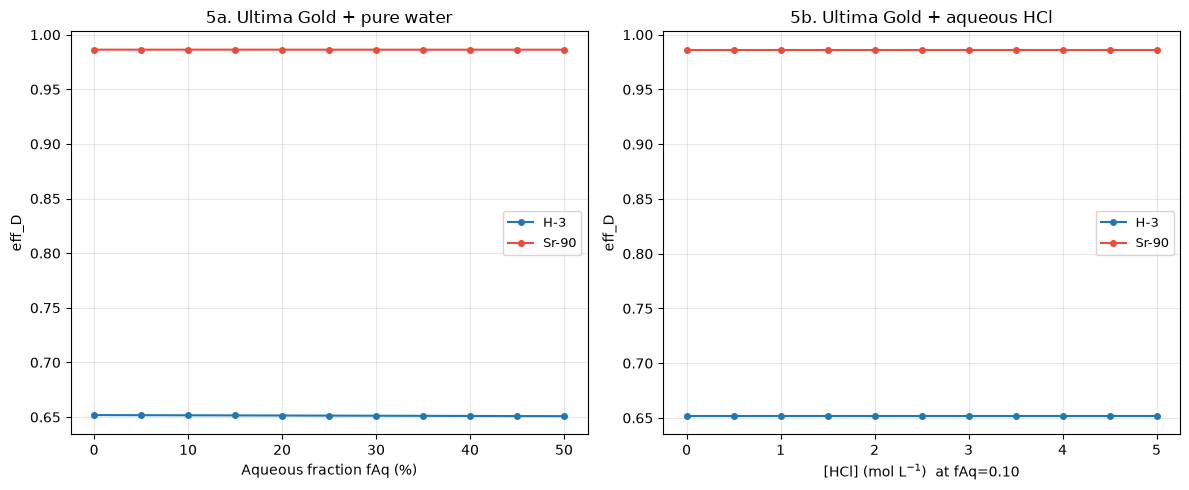

fAq 0→0.5:  H-3 eff_D 0.65181 -> 0.65080
HCl 0→5 mol/L (fAq=0.1):  H-3 eff_D 0.65161 -> 0.65161


In [7]:
fAq_vec = np.linspace(0.0, 0.5, 11)
resFaq = {rad: [] for rad in NUCLIDES}
for fAq in fAq_vec:
    tl.modifyLScocktail('Ultima Gold', float(fAq), 'Water', 0.0)
    tl = importlib.reload(tl)
    for rad in NUCLIDES:
        resFaq[rad].append(compute_efficiency(rad, NOMINAL['L'], NOMINAL['kB'])[1])
tl.modifyLScocktail(NOMINAL['ls_cocktail'], NOMINAL['fAq'], NOMINAL['solvantType'], NOMINAL['solvantConc'])
tl = importlib.reload(tl)

HCl_vec = np.linspace(0.0, 5.0, 11)
resHCl = {rad: [] for rad in NUCLIDES}
for conc in HCl_vec:
    tl.modifyLScocktail('Ultima Gold', 0.10, 'HCl', float(conc))
    tl = importlib.reload(tl)
    for rad in NUCLIDES:
        resHCl[rad].append(compute_efficiency(rad, NOMINAL['L'], NOMINAL['kB'])[1])
tl.modifyLScocktail(NOMINAL['ls_cocktail'], NOMINAL['fAq'], NOMINAL['solvantType'], NOMINAL['solvantConc'])
tl = importlib.reload(tl)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for rad in NUCLIDES:
    axes[0].plot(fAq_vec * 100, resFaq[rad], 'o-', color=COLORS[rad], ms=4, label=rad)
axes[0].set_xlabel('Aqueous fraction fAq (%)'); axes[0].set_ylabel('eff_D')
axes[0].set_title('5a. Ultima Gold + pure water'); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

for rad in NUCLIDES:
    axes[1].plot(HCl_vec, resHCl[rad], 'o-', color=COLORS[rad], ms=4, label=rad)
axes[1].set_xlabel('[HCl] (mol L$^{-1}$)  at fAq=0.10'); axes[1].set_ylabel('eff_D')
axes[1].set_title('5b. Ultima Gold + aqueous HCl'); axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig('sens_composition.png', dpi=150, bbox_inches='tight'); plt.show()

TORNADO['Aqueous fraction fAq (0\u21920.1)'] = (resFaq['H-3'][0], resFaq['H-3'][2], 'H-3')
TORNADO['[HCl] (0\u21925 mol/L, fAq=0.1)'] = (resHCl['H-3'][0], resHCl['H-3'][-1], 'H-3')
print(f"fAq 0\u21920.5:  H-3 eff_D {resFaq['H-3'][0]:.5f} -> {resFaq['H-3'][-1]:.5f}")
print(f"HCl 0\u21925 mol/L (fAq=0.1):  H-3 eff_D {resHCl['H-3'][0]:.5f} -> {resHCl['H-3'][-1]:.5f}")

QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.98 g/cm3
	Z = 3.2516, A = 5.9449
	Atomic fraction: H=0.5700, C=0.3903, N=0.0009, O=0.0353
	                 P=0.0026, S=0.0005, Na=0.0005, Cl=0.0000
	Micelle correction not activated

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 100 ns
	Extended dead time = 10.0 µs
	Measurement time = 60.0 min


QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold XR
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.99 g/cm3
	Z = 3.2146, A = 5.8553
	Atomic fraction: H=0.5851, C=0.3554, N=0.0007, O=0.0555
	                 P=0.0022, S=0.0006, Na=0.0006, Cl=0.0000
	Micelle correction not activated

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 100 ns
	Extended dead time = 10.0 µs
	Measurement time = 60.0 min


QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold AB
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.98 g/cm3
	Z = 3.2382, A = 5.9121
	Atomic fraction: H=0.5732, C=0.3755, N=0.0002, O=0.0509
	                 P=0.0002, S=0.0000, Na=0.0000, Cl=0.0000
	Micelle correction not activated

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 100 ns
	Extended dead time = 10.0 µs
	Measurement time = 60.0 min


QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold LLT
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.98 g/cm3
	Z = 3.2381, A = 5.9115
	Atomic fraction: H=0.5735, C=0.3745, N=0.0002, O=0.0516
	                 P=0.0002, S=0.0000, Na=0.0000, Cl=0.0000
	Micelle correction not activated

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 100 ns
	Extended dead time = 10.0 µs
	Measurement time = 60.0 min


QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Insta-Gel Plus
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.9500000000000001 g/cm3
	Z = 3.2483, A = 5.9253
	Atomic fraction: H=0.5796, C=0.3471, N=0.0001, O=0.0731
	                 P=0.0000, S=0.0000, Na=0.0000, Cl=0.0000
	Micelle correction not activated

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 100 ns
	Extended dead time = 10.0 µs
	Measurement time = 60.0 min


...

QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Permafluor E+
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.8999999999999999 g/cm3
	Z = 3.1405, A = 5.7106
	Atomic fraction: H=0.5795, C=0.4015, N=0.0000, O=0.0190
	                 P=0.0000, S=0.0000, Na=0.0000, Cl=0.0000
	Micelle correction not activated

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 100 ns
	Extended dead time = 10.0 µs
	Measurement time = 60.0 min


QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Carbo-Sorb/Permafluor (1:1)
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.8859999999999999 g/cm3
	Z = 3.0379, A = 5.4701
	Atomic fraction: H=0.6142, C=0.3161, N=0.0302, O=0.0395
	                 P=0.0000, S=0.0000, Na=0.0000, Cl=0.0000
	Micelle correction not activated

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 100 ns
	Extended dead time = 10.0 µs
	Measurement time = 60.0 min


QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = PXE
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.9850000000000001 g/cm3
	Z = 3.3524, A = 6.1848
	Atomic fraction: H=0.5295, C=0.4705, N=0.0000, O=0.0000
	                 P=0.0000, S=0.0000, Na=0.0000, Cl=0.0000
	Micelle correction not activated

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 100 ns
	Extended dead time = 10.0 µs
	Measurement time = 60.0 min


QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = LAB
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.86 g/cm3
	Z = 2.8397, A = 5.0565
	Atomic fraction: H=0.6321, C=0.3679, N=0.0000, O=0.0000
	                 P=0.0000, S=0.0000, Na=0.0000, Cl=0.0000
	Micelle correction not activated

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 100 ns
	Extended dead time = 10.0 µs
	Measurement time = 60.0 min


QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.98 g/cm3
	Z = 3.2516, A = 5.9449
	Atomic fraction: H=0.5700, C=0.3903, N=0.0009, O=0.0353
	                 P=0.0026, S=0.0005, Na=0.0005, Cl=0.0000
	Micelle correction not activated

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 100 ns
	Extended dead time = 10.0 µs
	Measurement time = 60.0 min


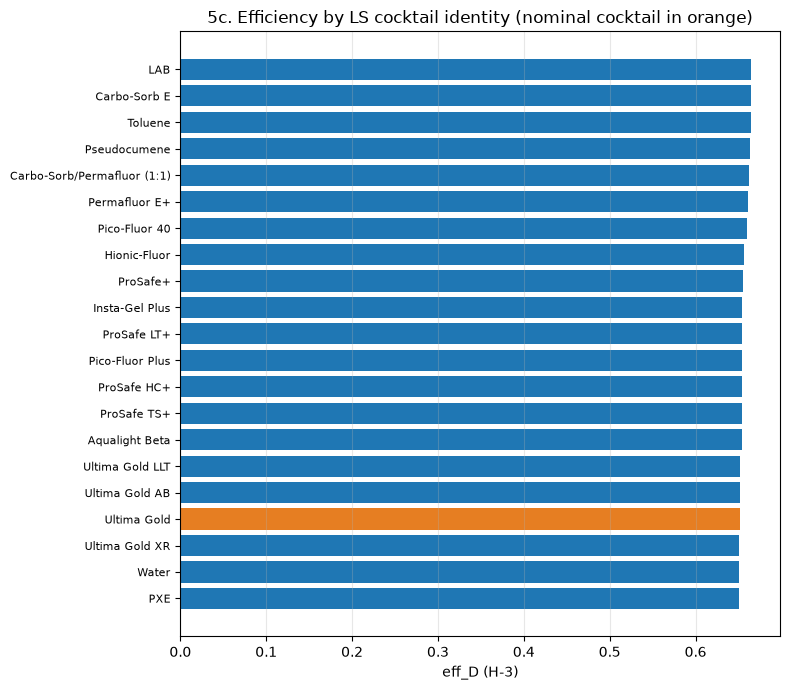

Lowest  eff_D: PXE                          0.65071
Highest eff_D: LAB                          0.66509


In [8]:
COCKTAILS = list(tl.COCKTAIL_DATA.keys())
resCock = []
for c in COCKTAILS:
    tl.modifyLScocktail(c, 0.0, 'Water', 0.0)
    tl = importlib.reload(tl)
    resCock.append(compute_efficiency('H-3', NOMINAL['L'], NOMINAL['kB'])[1])
tl.modifyLScocktail(NOMINAL['ls_cocktail'], NOMINAL['fAq'], NOMINAL['solvantType'], NOMINAL['solvantConc'])
tl = importlib.reload(tl)

order = np.argsort(resCock)
fig, ax = plt.subplots(figsize=(8, 7))
y = np.arange(len(COCKTAILS))
cols = ['#e67e22' if COCKTAILS[i] == NOMINAL['ls_cocktail'] else '#1f77b4' for i in order]
ax.barh(y, np.array(resCock)[order], color=cols)
ax.set_yticks(y); ax.set_yticklabels(np.array(COCKTAILS)[order], fontsize=8)
ax.set_xlabel('eff_D (H-3)'); ax.set_title('5c. Efficiency by LS cocktail identity (nominal cocktail in orange)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.savefig('sens_cocktail.png', dpi=150, bbox_inches='tight'); plt.show()

TORNADO['LS cocktail identity (min\u2194max)'] = (min(resCock), max(resCock), 'H-3, 21 cocktails')
imin, imax = int(np.argmin(resCock)), int(np.argmax(resCock))
print(f'Lowest  eff_D: {COCKTAILS[imin]:<28s} {resCock[imin]:.5f}')
print(f'Highest eff_D: {COCKTAILS[imax]:<28s} {resCock[imax]:.5f}')

## 6. Effective Z/A and density (isolated mass-stopping-power effect)

Part 5 changed Z, A and density *together* (as a consequence of composition).
Here each is perturbed independently, holding the other two fixed at their
Ultima Gold values, to isolate its individual weight in the stopping-power
formula.

QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.98 g/cm3
	Z = 3.2516, A = 5.9449
	Atomic fraction: H=0.5700, C=0.3903, N=0.0009, O=0.0353
	                 P=0.0026, S=0.0005, Na=0.0005, Cl=0.0000
	Micelle correction not activated

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 100 ns
	Extended dead time = 10.0 µs
	Measurement time = 60.0 min


QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.98 g/cm3
	Z = 3.2516, A = 5.9449
	Atomic fraction: H=0.5700, C=0.3903, N=0.0009, O=0.0353
	                 P=0.0026, S=0.0005, Na=0.0005, Cl=0.0000
	Micelle correction not activated

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 100 ns
	Extended dead time = 10.0 µs
	Measurement time = 60.0 min


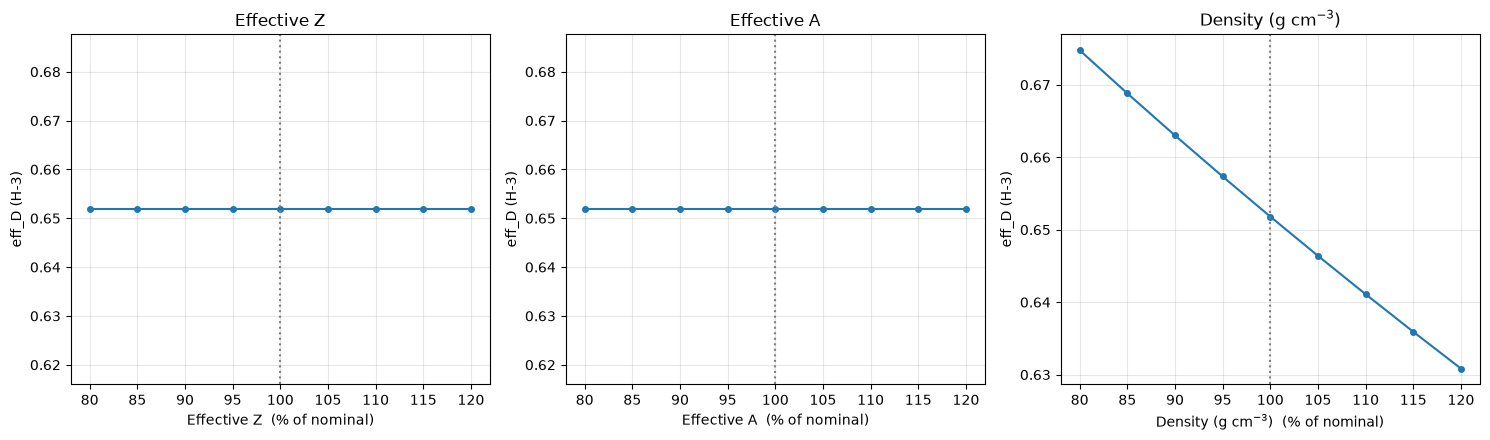

Z ±10%:       0.65181 -> 0.65181
A ±10%:       0.65181 -> 0.65181
density ±10%: 0.66882 -> 0.63591


In [9]:
tl.modifyLScocktail('Ultima Gold', 0.0, 'Water', 0.0)
tl = importlib.reload(tl)
Z0, A0, rho0 = tl.Z, tl.A, tl.RHO
scale_vec = np.linspace(0.8, 1.2, 9)

resZ, resA, resRho = [], [], []
for s in scale_vec:
    tl.modifyZ(Z0 * s); tl = importlib.reload(tl)
    resZ.append(compute_efficiency('H-3', NOMINAL['L'], NOMINAL['kB'])[1])
tl.modifyZ(Z0); tl = importlib.reload(tl)

for s in scale_vec:
    tl.modifyA(A0 * s); tl = importlib.reload(tl)
    resA.append(compute_efficiency('H-3', NOMINAL['L'], NOMINAL['kB'])[1])
tl.modifyA(A0); tl = importlib.reload(tl)

for s in scale_vec:
    tl.modifyDensity(rho0 * s); tl = importlib.reload(tl)
    resRho.append(compute_efficiency('H-3', NOMINAL['L'], NOMINAL['kB'])[1])
tl.modifyDensity(rho0); tl = importlib.reload(tl)
tl.modifyLScocktail(NOMINAL['ls_cocktail'], NOMINAL['fAq'], NOMINAL['solvantType'], NOMINAL['solvantConc'])
tl = importlib.reload(tl)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, res, name in zip(axes, [resZ, resA, resRho], ['Effective Z', 'Effective A', 'Density (g cm$^{-3}$)']):
    ax.plot(scale_vec * 100, res, 'o-', color='#1f77b4', ms=4)
    ax.axvline(100, color='gray', ls=':')
    ax.set_xlabel(f'{name}  (% of nominal)'); ax.set_ylabel('eff_D (H-3)')
    ax.set_title(name); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('sens_ZAdensity.png', dpi=150, bbox_inches='tight'); plt.show()

TORNADO['Effective Z (\u00b110%)'] = (resZ[1], resZ[-2], 'H-3, Ultima Gold baseline')
TORNADO['Effective A (\u00b110%)'] = (resA[1], resA[-2], 'H-3, Ultima Gold baseline')
TORNADO['Density (\u00b110%)'] = (resRho[1], resRho[-2], 'H-3, Ultima Gold baseline')
print(f'Z \u00b110%:       {resZ[1]:.5f} -> {resZ[-2]:.5f}')
print(f'A \u00b110%:       {resA[1]:.5f} -> {resA[-2]:.5f}')
print(f'density \u00b110%: {resRho[1]:.5f} -> {resRho[-2]:.5f}')

## 7. Low-energy stopping-power model and Chou bimolecular quenching

- **7a** — `sp_model`: which analytic formula describes electron stopping
  power below its validity cutoff (tan_xia/joy_luo ≤ 20 keV, others lower).
- **7b** — `chou_param`: an optional second-order (bimolecular) quenching
  term on top of Birks' law, `1/(1 + kB·S + kC·S²)`. Default is 0 (disabled).

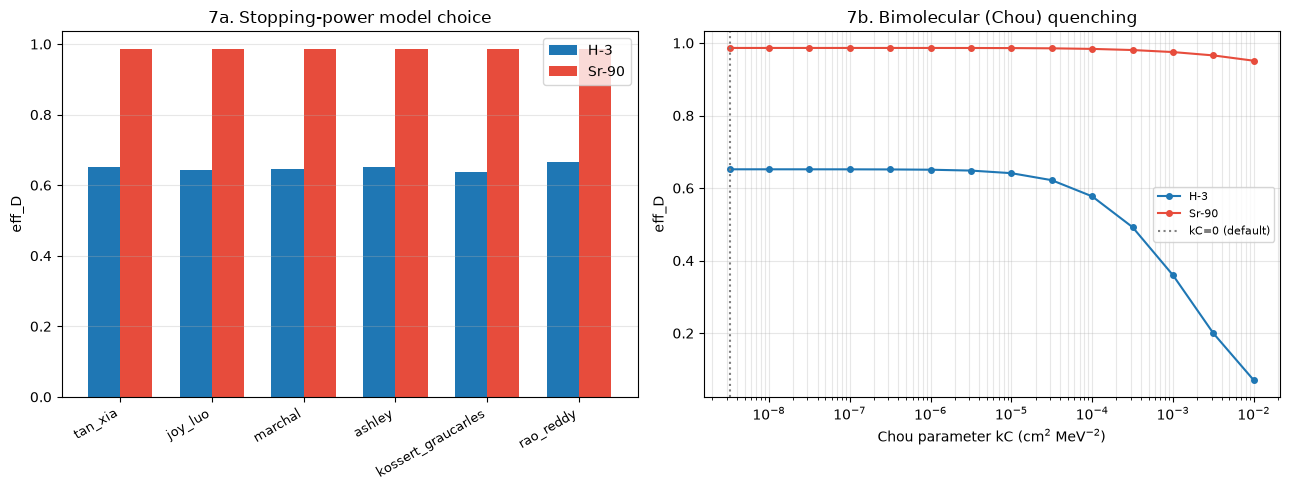

eff_D by stopping-power model (H-3):
  tan_xia                0.65181
  joy_luo                0.64382
  marchal                0.64627
  ashley                 0.65101
  kossert_graucarles     0.63733
  rao_reddy              0.66581


In [10]:
sp_models = ['tan_xia', 'joy_luo', 'marchal', 'ashley', 'kossert_graucarles', 'rao_reddy']
resSP = {rad: [] for rad in NUCLIDES}
for m in sp_models:
    tl.modifysp_model(m); tl = importlib.reload(tl)
    for rad in NUCLIDES:
        resSP[rad].append(compute_efficiency(rad, NOMINAL['L'], NOMINAL['kB'])[1])
tl.modifysp_model(NOMINAL['sp_model']); tl = importlib.reload(tl)

chou_vec = np.concatenate([[0.0], np.logspace(-8, -2, 13)])
resChou = {rad: [] for rad in NUCLIDES}
for kc in chou_vec:
    tl.modifyChou_param(float(kc)); tl = importlib.reload(tl)
    for rad in NUCLIDES:
        resChou[rad].append(compute_efficiency(rad, NOMINAL['L'], NOMINAL['kB'])[1])
tl.modifyChou_param(NOMINAL['chou_param']); tl = importlib.reload(tl)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(sp_models)); w = 0.35
ax = axes[0]
ax.bar(x - w/2, resSP['H-3'], w, color=COLORS['H-3'], label='H-3')
ax.bar(x + w/2, resSP['Sr-90'], w, color=COLORS['Sr-90'], label='Sr-90')
ax.set_xticks(x); ax.set_xticklabels(sp_models, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('eff_D'); ax.set_title('7a. Stopping-power model choice'); ax.legend(); ax.grid(axis='y', alpha=0.3)

ax = axes[1]
chou_plot = chou_vec.copy(); chou_plot[0] = chou_vec[1] / 3  # placeholder so log-x shows the kC=0 point
for rad in NUCLIDES:
    ax.semilogx(chou_plot, resChou[rad], 'o-', color=COLORS[rad], ms=4, label=rad)
ax.axvline(chou_plot[0], color='gray', ls=':', label='kC=0 (default)')
ax.set_xlabel('Chou parameter kC (cm$^2$ MeV$^{-2}$)'); ax.set_ylabel('eff_D')
ax.set_title('7b. Bimolecular (Chou) quenching'); ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.savefig('sens_spmodel_chou.png', dpi=150, bbox_inches='tight'); plt.show()

TORNADO['Stopping-power model (min\u2194max)'] = (min(resSP['H-3']), max(resSP['H-3']), 'H-3, 6 models')
i_1e4 = int(np.argmin(np.abs(chou_vec - 1e-4)))
TORNADO['Chou param kC (0\u21921e-4)'] = (resChou['H-3'][0], resChou['H-3'][i_1e4], 'H-3')
print('eff_D by stopping-power model (H-3):')
for m, v in zip(sp_models, resSP['H-3']):
    print(f'  {m:22s} {v:.5f}')

## 8. Quenching-integral numerics (ne, Einterp_e)

These are *computational* rather than physical parameters: they trade
accuracy for speed and should not materially change the physics result if
set adequately.

- **8a** — `nE_electron` (the `ne` integration-bin count): convergence of
  the exact Birks integral as the number of bins increases.
- **8b** — `Einterp_e`: the energy threshold below which the exact integral
  is used and above which the model falls back to a pre-tabulated spline
  (the module's normal fast path). Comparing `exact=True` vs `exact=False`
  quantifies the interpolation error this table introduces.

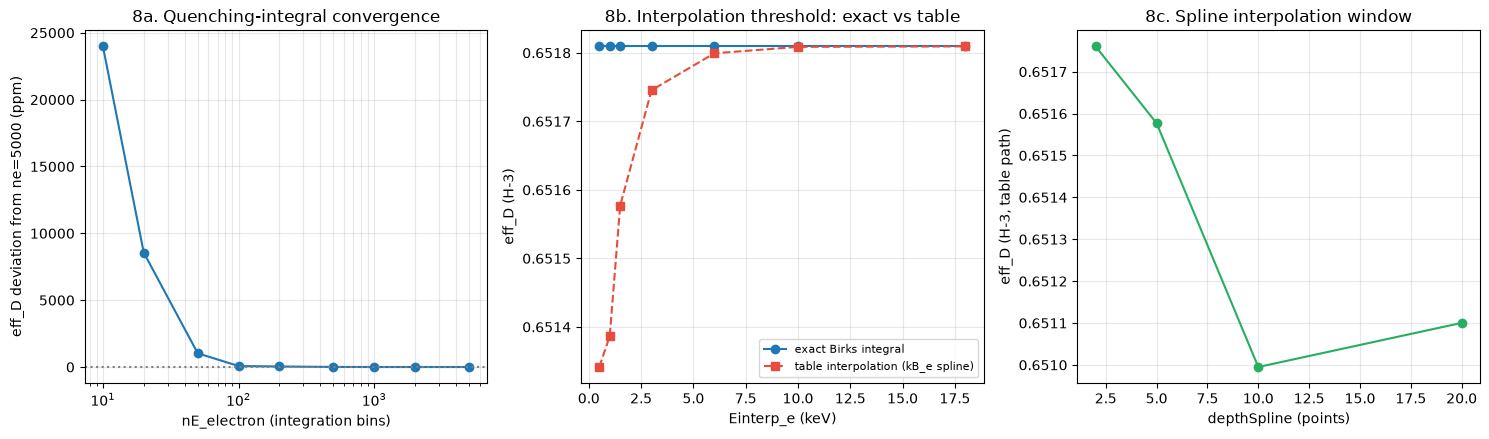

ne=100 vs ne=5000: eff_D deviation = 72.4 ppm
exact vs table interpolation @ Einterp_e=1.5: 0.651809 vs 0.651577
depthSpline 2→20: eff_D 0.651760 -> 0.651100


In [11]:
ne_vec = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000]
resNE = [compute_efficiency('H-3', NOMINAL['L'], NOMINAL['kB'], ne=n)[1] for n in ne_vec]
ref_ne = resNE[-1]
rel_err_ppm = [(v - ref_ne) / ref_ne * 1e6 for v in resNE]

Einterp_vec = [0.5, 1.0, 1.5, 3.0, 6.0, 10.0, 18.0]
resExact, resTable = [], []
for et in Einterp_vec:
    tl.modifyEinterp_e(et); tl = importlib.reload(tl)
    resExact.append(compute_efficiency('H-3', NOMINAL['L'], NOMINAL['kB'], exact=True)[1])
    resTable.append(compute_efficiency('H-3', NOMINAL['L'], NOMINAL['kB'], exact=False)[1])
tl.modifyEinterp_e(NOMINAL['Einterp_e']); tl = importlib.reload(tl)

depth_vec = [2, 5, 10, 20]
resDepth = []
for dp in depth_vec:
    tl.modifyDepthSpline(dp); tl = importlib.reload(tl)
    resDepth.append(compute_efficiency('H-3', NOMINAL['L'], NOMINAL['kB'], exact=False)[1])
tl.modifyDepthSpline(NOMINAL['depthSpline']); tl = importlib.reload(tl)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
ax = axes[0]
ax.semilogx(ne_vec, rel_err_ppm, 'o-', color='#1f77b4')
ax.axhline(0, color='gray', ls=':')
ax.set_xlabel('nE_electron (integration bins)'); ax.set_ylabel('eff_D deviation from ne=5000 (ppm)')
ax.set_title('8a. Quenching-integral convergence'); ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
ax.plot(Einterp_vec, resExact, 'o-', color='#1f77b4', label='exact Birks integral')
ax.plot(Einterp_vec, resTable, 's--', color='#e74c3c', label='table interpolation (kB_e spline)')
ax.set_xlabel('Einterp_e (keV)'); ax.set_ylabel('eff_D (H-3)')
ax.set_title('8b. Interpolation threshold: exact vs table'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(depth_vec, resDepth, 'o-', color='#27ae60')
ax.set_xlabel('depthSpline (points)'); ax.set_ylabel('eff_D (H-3, table path)')
ax.set_title('8c. Spline interpolation window'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('sens_numerics.png', dpi=150, bbox_inches='tight'); plt.show()

TORNADO['Quenching bins ne (100\u21925000)'] = (resNE[ne_vec.index(100)], resNE[-1], 'H-3, numerical')
print(f'ne=100 vs ne=5000: eff_D deviation = {rel_err_ppm[ne_vec.index(100)]:.1f} ppm')
print(f'exact vs table interpolation @ Einterp_e={NOMINAL["Einterp_e"]}: '
      f'{resExact[Einterp_vec.index(1.5)]:.6f} vs {resTable[Einterp_vec.index(1.5)]:.6f}')
print(f'depthSpline {depth_vec[0]}\u2192{depth_vec[-1]}: eff_D {resDepth[0]:.6f} -> {resDepth[-1]:.6f}')

## 9. Reverse-micelle correction (micCorr, diam_micelle)

Applies only in the **stochastic** engine (`tdcrpy.TDCRPy.TDCRPy`): for a
hydrophilic tracer dissolved in the aqueous micro-droplets of a
water-in-oil micellar system, this correction reduces the energy reaching
the surrounding scintillator. Tested with `fAq=0.10` (a representative small
aqueous fraction) and H-3, which is fast enough for a modest MC sample.

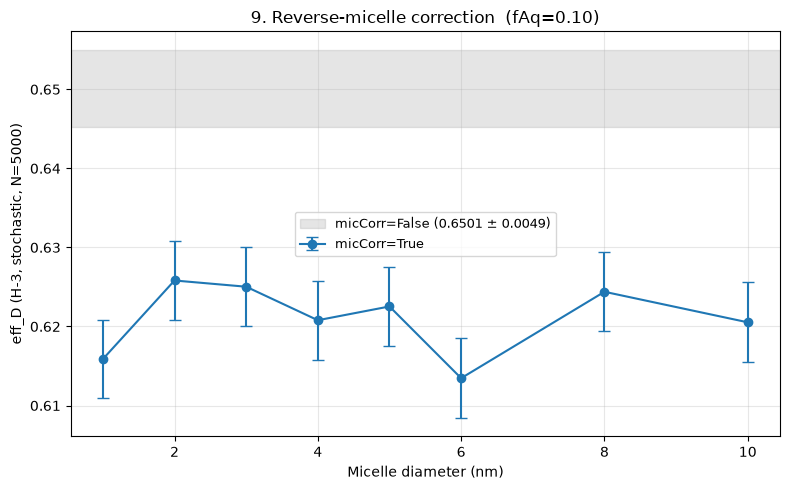

micCorr=False: eff_D = 0.65011 ± 0.00490
micCorr=True (mean over diam_micelle): eff_D = 0.62105 ± 0.00500


In [12]:
# No importlib.reload here: since 2.20.22 the micelle kernel resolves
# fAq, diam_micelle and sigma_micelle from the configuration on every
# call, and micCorr is read per call by _read_config(). Reloading a
# module full of @njit functions in a loop is what used to make this
# cell die with an LLVM symbol error.
N_MIC = 5000
tl.modifyfAq(0.10)
tl.modifyMicCorr(False)
out_off = tm.TDCRPy(NOMINAL['L'], 'H-3', '1', N_MIC, NOMINAL['kB'], NOMINAL['V'])
d_off, u_off = out_off[2], out_off[3]

diam_vec = [1, 2, 3, 4, 5, 6, 8, 10]
tl.modifyMicCorr(True)
resMic = []
for dia in diam_vec:
    tl.modifyDiam_micelle(dia)
    out = tm.TDCRPy(NOMINAL['L'], 'H-3', '1', N_MIC, NOMINAL['kB'], NOMINAL['V'])
    resMic.append((out[2], out[3]))

tl.modifyMicCorr(NOMINAL['micCorr']); tl.modifyDiam_micelle(NOMINAL['diam_micelle']); tl.modifyfAq(NOMINAL['fAq'])

d_on = np.array([v[0] for v in resMic]); u_on = np.array([v[1] for v in resMic])

fig, ax = plt.subplots(figsize=(8, 5))
ax.axhspan(d_off - u_off, d_off + u_off, color='gray', alpha=0.2, label=f'micCorr=False ({d_off:.4f} \u00b1 {u_off:.4f})')
ax.errorbar(diam_vec, d_on, yerr=u_on, fmt='o-', color=COLORS['H-3'], capsize=4, label='micCorr=True')
ax.set_xlabel('Micelle diameter (nm)'); ax.set_ylabel('eff_D (H-3, stochastic, N={})'.format(N_MIC))
ax.set_title('9. Reverse-micelle correction  (fAq=0.10)'); ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('sens_micelle.png', dpi=150, bbox_inches='tight'); plt.show()

TORNADO['Micelle correction on/off'] = (d_off, float(np.mean(d_on)), f'H-3, stochastic N={N_MIC}, fAq=0.1')
print(f'micCorr=False: eff_D = {d_off:.5f} \u00b1 {u_off:.5f}')
print(f'micCorr=True (mean over diam_micelle): eff_D = {np.mean(d_on):.5f} \u00b1 {np.mean(u_on):.5f}')

## 10. Counting-chain parameters (stochastic model): V, τ, extDT, measTime

These four parameters govern the physical counting chain rather than the
per-decay photon-production physics:

- **V** (scintillator volume, mL) — affects how much of a γ-ray's or
  X-ray's energy is actually deposited in the vial; tested with **Co-60**
  (β + 2 γ) since a pure β emitter is insensitive to volume.
- **τ** (coincidence resolving window, ns) — affects whether particles
  emitted with a time delay (e.g. an isomeric transition) are counted as
  coincident; tested with **Cd-109** (EC + delayed 88 keV IT γ).
- **extDT**, **measTime** — extended dead time and measurement duration:
  these govern pile-up/random-summing corrections for *sequences* of
  decays, not the per-decay efficiency returned here, so H-3 is used as a
  fast sanity check that they leave the single-decay efficiency unchanged.

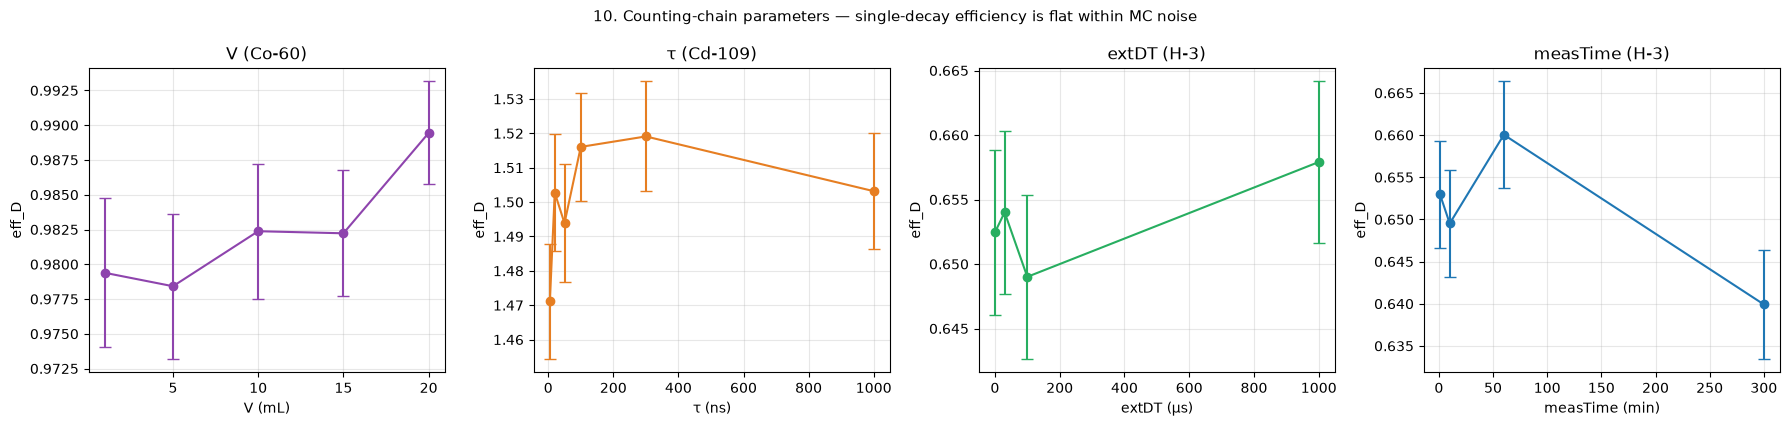

V, τ, extDT and measTime sweeps done — see figure. extDT/measTime excluded from the
summary ranking: their scatter is consistent with MC noise (they act on pile-up/random-summing
corrections applied on top of this per-decay efficiency, not on the efficiency itself).


In [13]:
# No importlib.reload here: tau, extDT and measTime are read from the
# configuration on every TDCRPy() call by _read_config().
N_SLOW, N_FAST = 500, 3000

V_vec = [1, 5, 10, 15, 20]
resV = [tm.TDCRPy(NOMINAL['L'], 'Co-60', '1', N_SLOW, NOMINAL['kB'], V)[2:4] for V in V_vec]

tau_vec = [5, 20, 50, 100, 300, 1000]
resTau = []
for tv in tau_vec:
    tl.modifyTau(tv)
    out = tm.TDCRPy(NOMINAL['L'], 'Cd-109', '1', N_SLOW, NOMINAL['kB'], NOMINAL['V'])
    resTau.append(out[2:4])
tl.modifyTau(NOMINAL['tau'])

extDT_vec = [0, 30, 100, 1000]
resEDT = []
for e in extDT_vec:
    tl.modifyDeadTime(e)
    out = tm.TDCRPy(NOMINAL['L'], 'H-3', '1', N_FAST, NOMINAL['kB'], NOMINAL['V'])
    resEDT.append(out[2:4])
tl.modifyDeadTime(NOMINAL['extDT'])

measTime_vec = [1, 10, 60, 300]
resMT = []
for mtv in measTime_vec:
    tl.modifyMeasTime(mtv)
    out = tm.TDCRPy(NOMINAL['L'], 'H-3', '1', N_FAST, NOMINAL['kB'], NOMINAL['V'])
    resMT.append(out[2:4])
tl.modifyMeasTime(NOMINAL['measTime'])

fig, axes = plt.subplots(1, 4, figsize=(18, 4.3))
for ax, xv, res, xlab, title, col in zip(
        axes, [V_vec, tau_vec, extDT_vec, measTime_vec],
        [resV, resTau, resEDT, resMT],
        ['V (mL)', '\u03c4 (ns)', 'extDT (\u00b5s)', 'measTime (min)'],
        ['V (Co-60)', '\u03c4 (Cd-109)', 'extDT (H-3)', 'measTime (H-3)'],
        ['#8e44ad', '#e67e22', '#27ae60', '#1f77b4']):
    d = [r[0] for r in res]; u = [r[1] for r in res]
    ax.errorbar(xv, d, yerr=u, fmt='o-', color=col, capsize=4)
    ax.set_xlabel(xlab); ax.set_ylabel('eff_D'); ax.set_title(title); ax.grid(alpha=0.3)
plt.suptitle('10. Counting-chain parameters — single-decay efficiency is flat within MC noise', fontsize=11)
plt.tight_layout(); plt.savefig('sens_counting_chain.png', dpi=150, bbox_inches='tight'); plt.show()

TORNADO['Scintillator volume V (1\u219220 mL)'] = (resV[0][0], resV[-1][0], f'Co-60, stochastic N={N_SLOW}')
TORNADO['Coincidence window \u03c4 (5\u21921000 ns)'] = (resTau[0][0], resTau[-1][0], f'Cd-109, stochastic N={N_SLOW}')
print('V, \u03c4, extDT and measTime sweeps done — see figure. extDT/measTime excluded from the')
print('summary ranking: their scatter is consistent with MC noise (they act on pile-up/random-summing')
print('corrections applied on top of this per-decay efficiency, not on the efficiency itself).')

## 11. Optical transport model and Monte-Carlo sample size

- **11a** — `opticalTransport`: semi-analytical Poisson detection model
  (default, fast) vs full photon Monte-Carlo transport (slower, more
  detailed optical physics).
- **11b** — `N`: number of Monte-Carlo decays. Not a physics parameter, but
  it is the stochastic engine's fundamental precision knob — shown here to
  confirm convergence to the analytical reference from Part 1.

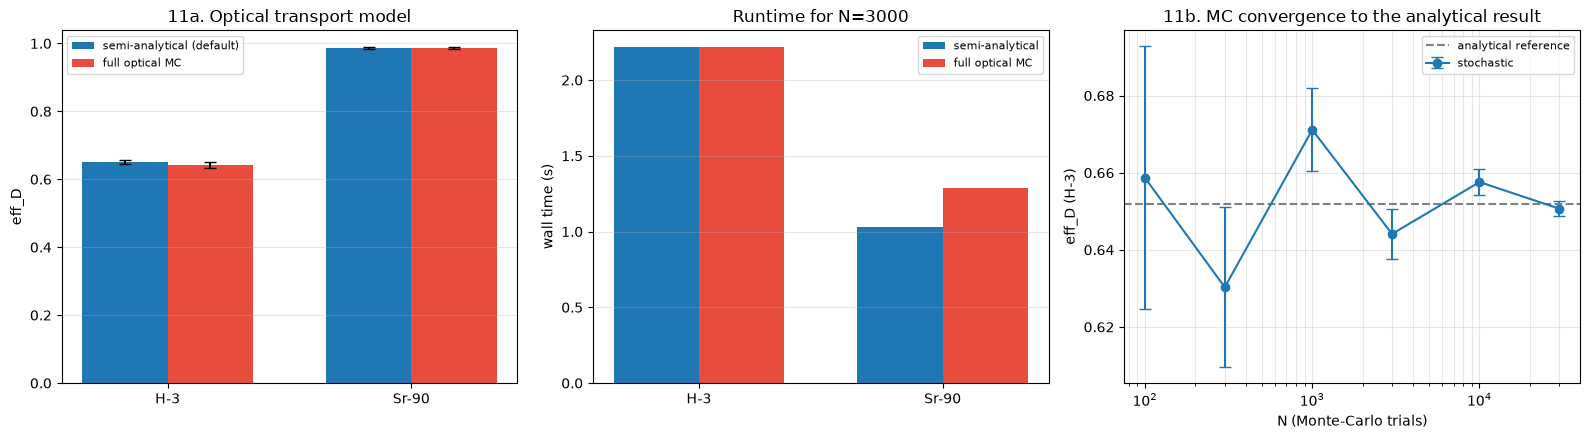

H-3 opticalTransport:  semi-analytical eff_D=0.65110  full-MC eff_D=0.64200
N convergence: eff_D(N=100)=0.65865 ± 0.03411   eff_D(N=30000)=0.65067 ± 0.00202   analytical=0.65181


In [14]:
# No importlib.reload here: since 2.20.24 TDCRPy() takes
# opticalTransport from the configuration when the argument is left
# at None.
N_OT = 3000
resOT = {}
timings = {}
for rad in NUCLIDES:
    tl.modifyOpticalTransport(False)
    t0 = time.time(); out_f = tm.TDCRPy(NOMINAL['L'], rad, '1', N_OT, NOMINAL['kB'], NOMINAL['V']); tf = time.time() - t0
    tl.modifyOpticalTransport(True)
    t0 = time.time(); out_t = tm.TDCRPy(NOMINAL['L'], rad, '1', N_OT, NOMINAL['kB'], NOMINAL['V']); tt = time.time() - t0
    resOT[rad] = dict(semi=(out_f[2], out_f[3], tf), full=(out_t[2], out_t[3], tt))
tl.modifyOpticalTransport(NOMINAL['opticalTransport'])

N_vec = [100, 300, 1000, 3000, 10000, 30000]
resN = [tm.TDCRPy(NOMINAL['L'], 'H-3', '1', N, NOMINAL['kB'], NOMINAL['V'])[2:4] for N in N_vec]
ref_analytical = compute_efficiency('H-3', NOMINAL['L'], NOMINAL['kB'])[1]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
ax = axes[0]
x = np.arange(len(NUCLIDES)); w = 0.35
semi_d = [resOT[r]['semi'][0] for r in NUCLIDES]; semi_u = [resOT[r]['semi'][1] for r in NUCLIDES]
full_d = [resOT[r]['full'][0] for r in NUCLIDES]; full_u = [resOT[r]['full'][1] for r in NUCLIDES]
ax.bar(x - w/2, semi_d, w, yerr=semi_u, capsize=4, color='#1f77b4', label='semi-analytical (default)')
ax.bar(x + w/2, full_d, w, yerr=full_u, capsize=4, color='#e74c3c', label='full optical MC')
ax.set_xticks(x); ax.set_xticklabels(NUCLIDES); ax.set_ylabel('eff_D')
ax.set_title('11a. Optical transport model'); ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

ax = axes[1]
ax.bar(x - w/2, [resOT[r]['semi'][2] for r in NUCLIDES], w, color='#1f77b4', label='semi-analytical')
ax.bar(x + w/2, [resOT[r]['full'][2] for r in NUCLIDES], w, color='#e74c3c', label='full optical MC')
ax.set_xticks(x); ax.set_xticklabels(NUCLIDES); ax.set_ylabel('wall time (s)')
ax.set_title(f'Runtime for N={N_OT}'); ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

ax = axes[2]
d_n = [r[0] for r in resN]; u_n = [r[1] for r in resN]
ax.errorbar(N_vec, d_n, yerr=u_n, fmt='o-', color=COLORS['H-3'], capsize=4, label='stochastic')
ax.axhline(ref_analytical, color='gray', ls='--', label='analytical reference')
ax.set_xscale('log'); ax.set_xlabel('N (Monte-Carlo trials)'); ax.set_ylabel('eff_D (H-3)')
ax.set_title('11b. MC convergence to the analytical result'); ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.savefig('sens_opticalMC_N.png', dpi=150, bbox_inches='tight'); plt.show()

TORNADO['Optical transport (semi\u2194full MC)'] = (resOT['H-3']['semi'][0], resOT['H-3']['full'][0], f'H-3, stochastic N={N_OT}')
print(f"H-3 opticalTransport:  semi-analytical eff_D={resOT['H-3']['semi'][0]:.5f}  "
      f"full-MC eff_D={resOT['H-3']['full'][0]:.5f}")
print(f'N convergence: eff_D(N={N_vec[0]})={d_n[0]:.5f} \u00b1 {u_n[0]:.5f}   '
      f'eff_D(N={N_vec[-1]})={d_n[-1]:.5f} \u00b1 {u_n[-1]:.5f}   analytical={ref_analytical:.5f}')

## 12. Summary — sensitivity ranking

Every perturbation collected above (`TORNADO`), ranked by how much it moves
`eff_D` away from its nominal value. Bars use a realistic (not extreme)
perturbation for each parameter — see the note in each entry's label/caption
for the exact range and nuclide used.

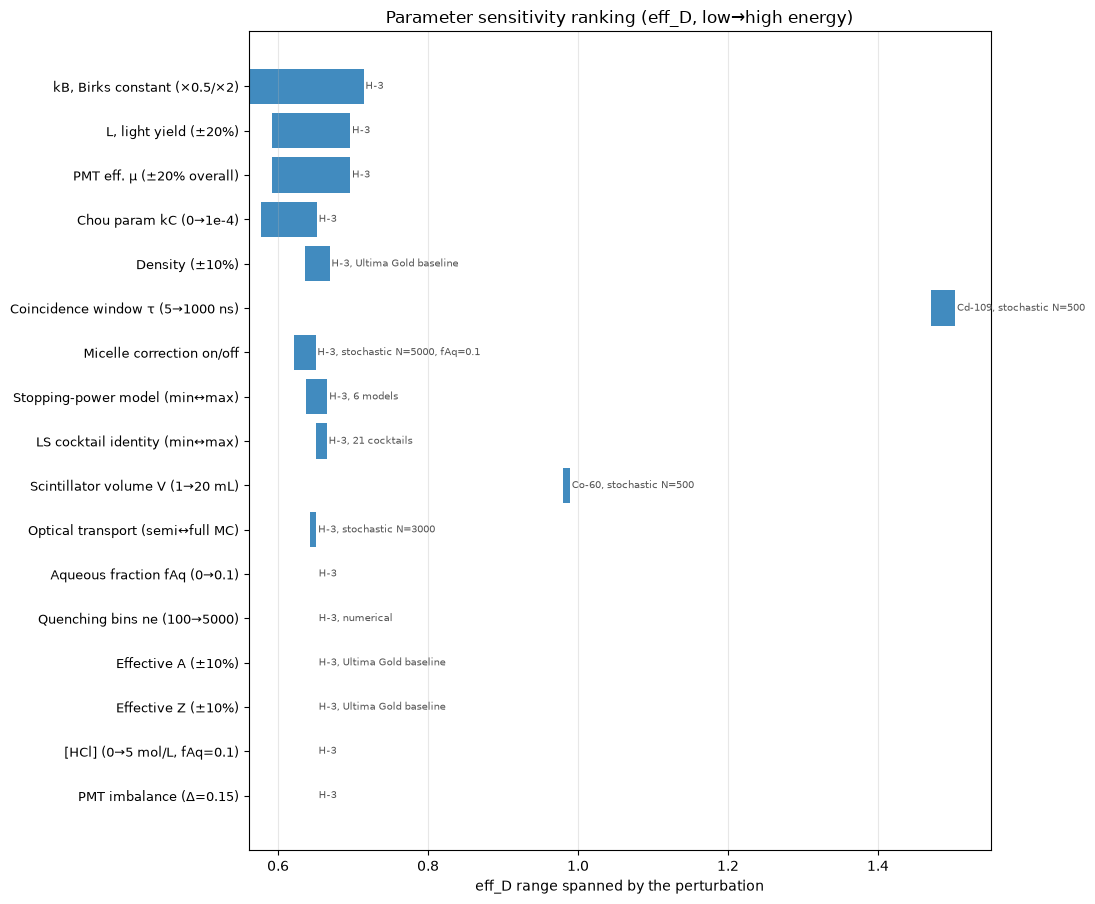

Parameter                                    low      high      span   note
----------------------------------------------------------------------------------------------------
kB, Birks constant (×0.5/×2)             0.56082   0.71419   0.15338   H-3
L, light yield (±20%)                    0.59122   0.69631   0.10509   H-3
PMT eff. μ (±20% overall)                0.59122   0.69631   0.10509   H-3
Chou param kC (0→1e-4)                   0.57722   0.65181   0.07459   H-3
Density (±10%)                           0.63591   0.66882   0.03290   H-3, Ultima Gold baseline
Coincidence window τ (5→1000 ns)         1.47111   1.50318   0.03207   Cd-109, stochastic N=500
Micelle correction on/off                0.62105   0.65011   0.02906   H-3, stochastic N=5000, fAq=0.1
Stopping-power model (min↔max)           0.63733   0.66581   0.02849   H-3, 6 models
LS cocktail identity (min↔max)           0.65071   0.66509   0.01438   H-3, 21 cocktails
Scintillator volume V (1→20 mL)          0.97939   0.

In [15]:
labels = list(TORNADO.keys())
los = np.array([TORNADO[k][0] for k in labels])
his = np.array([TORNADO[k][1] for k in labels])
notes = [TORNADO[k][2] for k in labels]

lo_bound = np.minimum(los, his)
hi_bound = np.maximum(los, his)
span = hi_bound - lo_bound
order = np.argsort(span)  # ascending, so largest ends up on top of a barh plot

fig, ax = plt.subplots(figsize=(11, 0.42 * len(labels) + 2))
y = np.arange(len(labels))
ax.barh(y, span[order], left=lo_bound[order], color='#1f77b4', alpha=0.85)
for i, idx in enumerate(order):
    ax.text(hi_bound[idx] + span.max() * 0.015, i, notes[idx], va='center', fontsize=7, color='#555555')
ax.set_yticks(y); ax.set_yticklabels(np.array(labels)[order], fontsize=9)
ax.set_xlabel('eff_D range spanned by the perturbation')
ax.set_title('Parameter sensitivity ranking (eff_D, low\u2192high energy)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.savefig('sens_tornado.png', dpi=150, bbox_inches='tight'); plt.show()

print(f"{'Parameter':38s} {'low':>9s} {'high':>9s} {'span':>9s}   note")
print('-' * 100)
for idx in order[::-1]:
    print(f'{labels[idx]:38s} {lo_bound[idx]:9.5f} {hi_bound[idx]:9.5f} {span[idx]:9.5f}   {notes[idx]}')

## 13. Restore configuration and conclusions

Reset `tdcrpy/config.toml` to the nominal values captured in Part 0.

In [16]:
restore_defaults()
print('Configuration restored to nominal values. Final check:')
tl.readParameters(disp=True)

QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.98 g/cm3
	Z = 3.2516, A = 5.9449
	Atomic fraction: H=0.5700, C=0.3903, N=0.0009, O=0.0353
	                 P=0.0026, S=0.0005, Na=0.0005, Cl=0.0000
	Micelle correction not activated

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 100 ns
	Extended dead time = 10.0 µs
	Measurement time = 60.0 min


Configuration restored to nominal values. Final check:
QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.0 (Type: Water, 0.0 mol/L)
	Density = 0.98 g/cm3
	Z = 3.2516, A = 5.9449
	Atomic fraction: H=0.5700, C=0.3903, N=0.0009, O=0.0353
	                 P=0.0026, S=0.0005, Na=0.0005, Cl=0.0000
	Micelle correction not activated

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250
	Optical transport (full MC) = False

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 100 ns
	Extended dead time = 10.0 µs
	Measurement time = 60.0 min


(1000,
 1000,
 0.98,
 3.251555708075745,
 5.944938275747905,
 5,
 100.0,
 1.5,
 4.0,
 0.0,
 100,
 10.0,
 60.0,
 False,
 [0.25, 0.25, 0.25],
 False,
 0.569971,
 0.390337,
 0.000933,
 0.035279,
 0.002551,
 0.000463,
 0.000465,
 0.0,
 'Water',
 0.0,
 'tan_xia',
 0.0,
 0.0)

### Conclusions

- **Dominant parameters** — the free light-yield parameter `L`, the Birks
  constant `kB`, and the PMT quantum efficiency `effQuantum` are, by a wide
  margin, the parameters the computed efficiency is most sensitive to: they
  directly set the mean number of photoelectrons per PMT and therefore
  saturate or starve the whole detection-probability chain.
- **Composition-driven parameters** — aqueous fraction, solvent, cocktail
  identity, effective Z/A and density all act *through* the stopping-power /
  quenching chain and produce second-order effects, typically well below the
  L/kB/effQuantum contribution for realistic composition changes, but not
  negligible for large aqueous fractions or unusual cocktails.
- **Numerical parameters** (`nE_electron`, `Einterp_e`, `depthSpline`) are,
  as intended, essentially inert once past a modest bin count — they trade
  runtime for accuracy rather than changing the physics.
- **Counting-chain parameters** (`V`, `extDT`, `measTime`) leave the
  per-decay efficiency unchanged for pure single-decay simulations; they
  matter for pile-up/random-summing corrections applied on top of this
  efficiency at high count rates, outside the scope of this notebook.
  The coincidence window `τ` is the exception among this group: it can
  measurably affect nuclides with delayed cascades (e.g. Cd-109).
- **H-3 is consistently the most responsive nuclide** across every section,
  and **Sr-90 the least**, because Sr-90's high-energy β spectrum already
  produces detection probabilities close to saturation (pe → 1) for most of
  its energy range, making it inherently insensitive to further increases in
  light yield.